In [6]:
!pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train,y_train),(X_test,y_test)=keras.datasets.fashion_mnist.load_data()

In [10]:
X_train.shape

(60000, 28, 28)

In [11]:
y_train.shape

(60000,)

In [12]:
X_train.dtype

dtype('uint8')

In [13]:
X_val,X_train=X_train[:5000]/255,X_train[5000:]/255
y_val,y_train=y_train[:5000],y_train[5000:]
X_test=X_test/255

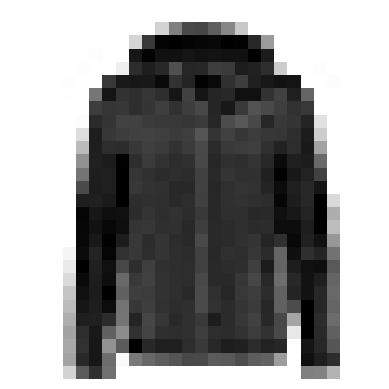

In [15]:
plt.imshow(X_train[0],cmap="binary")                   # display image
plt.axis('off')                   # optional: hide axes
plt.show()

In [16]:
print(y_train[0])

4


In [23]:
np.random.seed(42)
tf.random.set_seed(42)

In [24]:
# Creating the architecture

model=keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation="relu"))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dense(10,activation="softmax"))

In [26]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
weight,bias=model.layers[1].get_weights()

In [30]:
print(weight.shape)
print(weight)

(784, 300)
[[ 0.01189312 -0.0568459   0.04186735 ... -0.00087396 -0.0673926
  -0.03961781]
 [-0.07094629  0.04891402 -0.06418785 ...  0.04972612  0.05860706
  -0.0730354 ]
 [-0.00546906  0.01431239 -0.00590951 ... -0.03673641 -0.07096583
   0.04972428]
 ...
 [-0.01725008 -0.05051915  0.00977661 ... -0.03156551 -0.04498735
  -0.01822603]
 [ 0.055811   -0.04736246 -0.01677586 ...  0.04335289 -0.05506158
  -0.0466505 ]
 [ 0.00272569 -0.05006293  0.03933719 ...  0.0740591   0.03658539
  -0.04551379]]


In [31]:
print(bias.shape)
print(bias)

(300,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [32]:
# specifying the loss,optimiser,evaluation metrics
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

In [33]:
trained_model=model.fit(X_train,y_train,epochs=30,validation_data=(X_val,y_val))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7615 - loss: 0.7176 - val_accuracy: 0.8214 - val_loss: 0.5228
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8299 - loss: 0.4878 - val_accuracy: 0.8418 - val_loss: 0.4548
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8446 - loss: 0.4414 - val_accuracy: 0.8518 - val_loss: 0.4228
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8552 - loss: 0.4139 - val_accuracy: 0.8574 - val_loss: 0.4016
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8622 - loss: 0.3940 - val_accuracy: 0.8608 - val_loss: 0.3859
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8662 - loss: 0.3780 - val_accuracy: 0.8682 - val_loss: 0.3738
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8705 - loss: 0.3646 - val_accuracy: 0.8698 - val_loss: 0.3649
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8741 - loss: 0

In [39]:
trained_model.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [41]:
trained_model.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [42]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8806 - loss: 0.3413


[0.3413148522377014, 0.8805999755859375]

**OPTIMISING THE MODEL**

In [3]:
X_val,X_train=X_train[:5000]/255,X_train[5000:]/255
y_val,y_train=y_train[:5000],y_train[5000:]
X_test=X_test/255

np.random.seed(42)
tf.random.set_seed(42)

In [7]:
# Creating the architecture

model=keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation="relu"))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(10,activation="softmax"))

In [8]:
# specifying the loss,optimiser,evaluation metrics
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [9]:
model.fit(X_train,y_train,epochs=15,validation_data=(X_val,y_val))

Epoch 1/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.7411 - loss: 0.7191 - val_accuracy: 0.8454 - val_loss: 0.4261
Epoch 2/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8160 - loss: 0.5189 - val_accuracy: 0.8516 - val_loss: 0.4109
Epoch 3/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8261 - loss: 0.4826 - val_accuracy: 0.8638 - val_loss: 0.3794
Epoch 4/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8362 - loss: 0.4582 - val_accuracy: 0.8620 - val_loss: 0.3684
Epoch 5/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8416 - loss: 0.4411 - val_accuracy: 0.8696 - val_loss: 0.3453
Epoch 6/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8461 - loss: 0.4294 - val_accuracy: 0.8694 - val_loss: 0.3540
Epoch 7/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8494 - loss: 0.4177 - val_accuracy: 0.8750 - val_loss: 0.3399
Epoch 8/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8519 - loss:

In [10]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8662 - loss: 0.3629


[0.3629167973995209, 0.8661999702453613]

In [17]:
# Creating the architecture

model=keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(128,activation="relu"))
#model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(64,activation="relu"))
#model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(10,activation="softmax"))

# specifying the loss,optimiser,evaluation metrics
model.compile(
    loss="sparse_categorical_crossentropy",
    #optimizer="adam",
    optimizer="sgd",
    metrics=["accuracy"]
)

model.fit(X_train,y_train,epochs=25,validation_data=(X_val,y_val))

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7525 - loss: 0.7484 - val_accuracy: 0.8152 - val_loss: 0.5381
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8265 - loss: 0.4989 - val_accuracy: 0.8390 - val_loss: 0.4721
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8424 - loss: 0.4521 - val_accuracy: 0.8512 - val_loss: 0.4400
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8512 - loss: 0.4249 - val_accuracy: 0.8584 - val_loss: 0.4165
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8574 - loss: 0.4055 - val_accuracy: 0.8642 - val_loss: 0.3991
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8619 - loss: 0.3905 - val_accuracy: 0.8684 - val_loss: 0.3871
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8663 - loss: 0.3778 - val_accuracy: 0.8694 - val_loss: 0.3775
Epoch 8/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8696 - loss: 0.366

In [18]:
# [0.38471436500549316, 0.8622999787330627]
# model.evaluate(X_test,y_test)

model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8754 - loss: 0.3501


[0.3500816524028778, 0.8754000067710876]